# Experiment 3.0.2 — Hidden multi-τ architecture comparison

This notebook is **analysis-only**. Formal execution is:

`Slurm training array → Slurm evaluation array → finalizer → this notebook`

Architectures:

- **A**: L1=(3), L2=(3), L3=(3); reused from Experiment 3.0.1 `paired_split_v2`.
- **B**: L1=(2,3), L2=(2,3), L3=(3).
- **C**: L1=(2,3,4), L2=(2,3,4), L3=(3).
- **D**: L1=(2,3), L2=(2,3,4,5), L3=(3).
- **E**: L1=(2,3), L2=(2,3,4), L3=(3).

All architectures use the same 30→128→128→64 SNN backbone, the same fixed user split, three objectives (`timestep_ce`, `relative10_sequence_ce`, `fixed250_sequence_ce`) and seeds 11/23/101. L3 is intentionally fixed at shift 3 so the experiment isolates hidden-layer temporal organization.


In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 220)

def find_repo_root(start=Path.cwd()):
    start = start.resolve()
    for p in (start, *start.parents):
        if (p / 'snn').is_dir() and (p / 'notebooks').is_dir():
            return p
    raise FileNotFoundError('Could not locate writingRing repository root')

REPO_ROOT = find_repo_root()
RESULTS_DIR = REPO_ROOT / 'notebooks' / 'artifacts' / 'experiment_3_0_2_hidden_multitau_architecture_comparison' / 'hidden_multitau_v1'
print('Repository root:', REPO_ROOT)
print('Results dir:', RESULTS_DIR)


Repository root: /home/zhaolongwei_umass_edu/projects/writingRing
Results dir: /home/zhaolongwei_umass_edu/projects/writingRing/notebooks/artifacts/experiment_3_0_2_hidden_multitau_architecture_comparison/hidden_multitau_v1


In [2]:
FILES = {
    'architectures': 'experiment_3_0_2_architectures.csv',
    'native': 'experiment_3_0_2_native_results.csv',
    'history': 'experiment_3_0_2_history.csv',
    'layer_probes': 'experiment_3_0_2_layer_probes.csv',
    'subgroup_probes': 'experiment_3_0_2_tau_subgroup_probes.csv',
    'firing': 'experiment_3_0_2_firing_rates.csv',
    'native_summary': 'experiment_3_0_2_native_summary.csv',
    'layer_probe_summary': 'experiment_3_0_2_layer_probe_summary.csv',
    'subgroup_probe_summary': 'experiment_3_0_2_tau_subgroup_probe_summary.csv',
    'firing_summary': 'experiment_3_0_2_firing_rate_summary.csv',
}
missing = [name for name in FILES.values() if not (RESULTS_DIR / name).exists()]
if missing:
    raise FileNotFoundError('Run the Slurm pipeline/finalizer first. Missing: ' + ', '.join(missing))

tables = {key: pd.read_csv(RESULTS_DIR / name) for key, name in FILES.items()}
native = tables['native']
history = tables['history']
layer_probes = tables['layer_probes']
subgroup_probes = tables['subgroup_probes']
firing = tables['firing']
native_summary = tables['native_summary']
layer_probe_summary = tables['layer_probe_summary']
subgroup_probe_summary = tables['subgroup_probe_summary']
firing_summary = tables['firing_summary']

assert len(native) == 45, len(native)
display(tables['architectures'])
display(native_summary.sort_values(['objective', 'mean_test_balanced_accuracy'], ascending=[True, False]))


,architecture,layer,layer_width,shifts,shift,group_neurons,tau_syn_ms
0,A,L1,128,3,3,128,117.013683
1,A,L2,128,3,3,128,117.013683
2,A,L3,64,3,3,64,117.013683
3,B,L1,128,"2,3",2,64,54.313430
4,B,L1,128,"2,3",3,64,117.013683
5,B,L2,128,"2,3",2,64,54.313430
6,B,L2,128,"2,3",3,64,117.013683
7,B,L3,64,3,3,64,117.013683
8,C,L1,128,"2,3,4",2,43,54.313430
9,C,L1,128,"2,3,4",3,43,117.013683


,objective,architecture,mean_test_balanced_accuracy,mean_test_macro_f1,mean_test_accuracy,mean_val_balanced_accuracy,mean_train_balanced_accuracy,mean_train_test_ba_gap,mean_best_epoch,sd_test_balanced_accuracy,sd_test_macro_f1,sd_test_accuracy,sd_val_balanced_accuracy,sd_train_balanced_accuracy,sd_train_test_ba_gap,sd_best_epoch
2,fixed250_sequence_ce,C,0.490975,0.486005,0.500000,0.507449,0.973263,0.482288,75.000000,0.020595,0.023635,0.018122,0.014174,0.012494,0.020190,5.291503
1,fixed250_sequence_ce,B,0.484617,0.480318,0.493151,0.514891,0.944535,0.459917,80.666667,0.023961,0.028890,0.023727,0.031910,0.023637,0.010482,15.011107
4,fixed250_sequence_ce,E,0.457082,0.457298,0.470320,0.504794,0.952479,0.495397,85.666667,0.027618,0.020413,0.027681,0.006305,0.008603,0.025971,12.583057
0,fixed250_sequence_ce,A,0.453162,0.447141,0.465753,0.497657,0.939502,0.486341,68.333333,0.007486,0.005369,0.013699,0.046088,0.057551,0.053469,22.744963
3,fixed250_sequence_ce,D,0.438227,0.435344,0.447489,0.486672,0.957600,0.519373,92.000000,0.022113,0.023234,0.025931,0.024225,0.012623,0.034621,4.358899
6,relative10_sequence_ce,B,0.586775,0.586852,0.591324,0.568561,0.969179,0.382404,82.333333,0.020078,0.023590,0.015818,0.012279,0.008245,0.012694,14.571662
5,relative10_sequence_ce,A,0.568385,0.570236,0.573059,0.603882,0.973797,0.405412,88.000000,0.032652,0.025927,0.033787,0.021847,0.005818,0.036364,11.532563
7,relative10_sequence_ce,C,0.561331,0.559372,0.570776,0.564873,0.976854,0.415524,80.000000,0.031037,0.023829,0.027681,0.019835,0.005075,0.034896,16.643317
8,relative10_sequence_ce,D,0.555582,0.550356,0.566210,0.568817,0.955948,0.400366,95.666667,0.080525,0.079760,0.078792,0.024353,0.012984,0.067870,3.785939
9,relative10_sequence_ce,E,0.532746,0.526777,0.538813,0.569701,0.939094,0.406348,84.333333,0.023980,0.025699,0.027681,0.018295,0.049042,0.030267,23.755701


## 1. Native test balanced accuracy
Compare A–E under each native training objective.

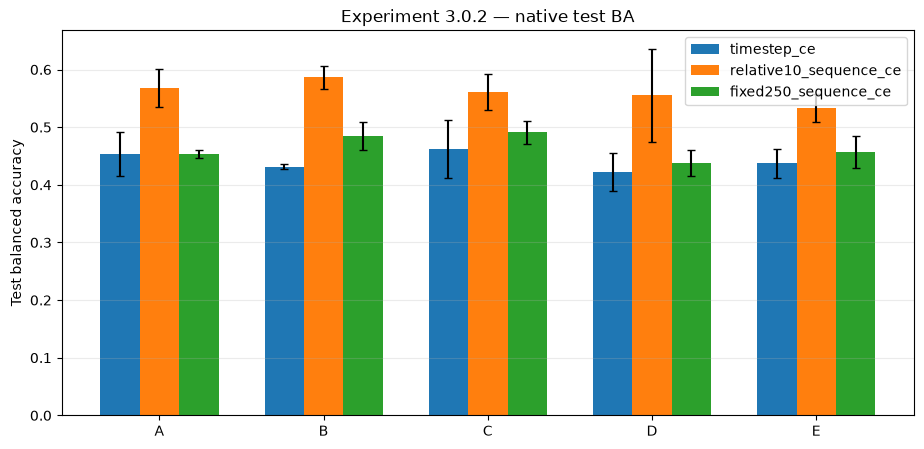

In [3]:
objectives = ['timestep_ce', 'relative10_sequence_ce', 'fixed250_sequence_ce']
architectures = ['A', 'B', 'C', 'D', 'E']
x = np.arange(len(architectures))
width = 0.24
fig, ax = plt.subplots(figsize=(11, 5))
for i, objective in enumerate(objectives):
    d = native_summary[native_summary.objective == objective].set_index('architecture').reindex(architectures)
    ax.bar(x + (i - 1) * width, d.mean_test_balanced_accuracy, width, yerr=d.sd_test_balanced_accuracy, capsize=3, label=objective)
ax.set_xticks(x, architectures)
ax.set_ylabel('Test balanced accuracy')
ax.set_title('Experiment 3.0.2 — native test BA')
ax.legend()
ax.grid(axis='y', alpha=0.25)
plt.show()


## 2. Layer-wise frozen linear probes
Each trained SNN is frozen. L1/L2/L3 are independently evaluated with full-count and fixed-250-ms representations followed by StandardScaler + LogisticRegression.

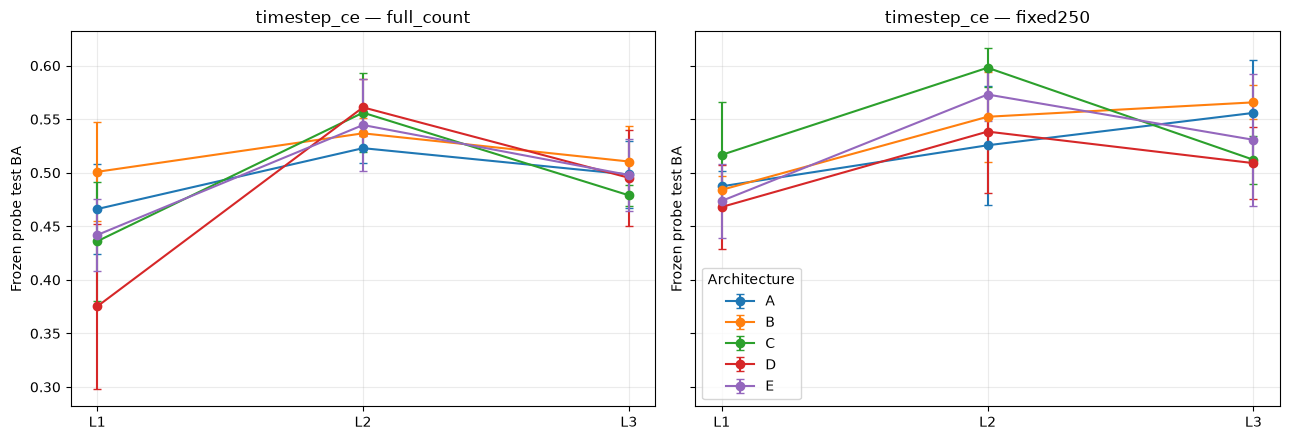

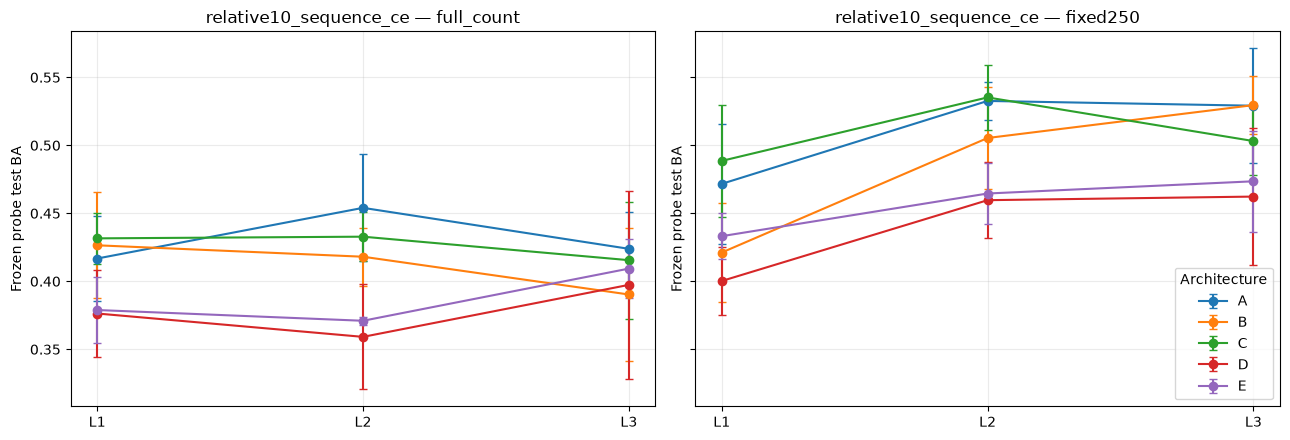

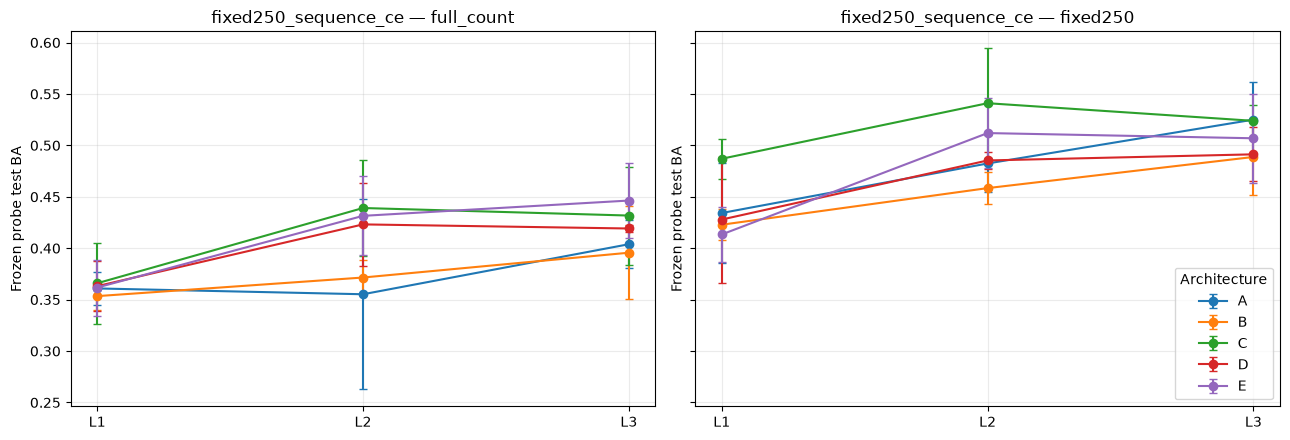

In [4]:
for objective in objectives:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
    for ax, probe_type in zip(axes, ['full_count', 'fixed250']):
        d = layer_probe_summary[(layer_probe_summary.objective == objective) & (layer_probe_summary.probe_type == probe_type)]
        for architecture in architectures:
            q = d[d.architecture == architecture].set_index('layer').reindex(['L1', 'L2', 'L3'])
            ax.errorbar(['L1', 'L2', 'L3'], q.mean_probe_test_balanced_accuracy, yerr=q.sd_probe_test_balanced_accuracy, marker='o', capsize=3, label=architecture)
        ax.set_title(f'{objective} — {probe_type}')
        ax.set_ylabel('Frozen probe test BA')
        ax.grid(alpha=0.25)
    axes[-1].legend(title='Architecture')
    plt.tight_layout()
    plt.show()


## 3. L3 fixed250 probe versus native classifier
This separates native readout quality from the discriminative information contained in the final 64-neuron feature layer.

In [5]:
l3 = layer_probe_summary[(layer_probe_summary.layer == 'L3') & (layer_probe_summary.probe_type == 'fixed250')]
comparison = native_summary.merge(
    l3[['objective', 'architecture', 'mean_probe_test_balanced_accuracy', 'sd_probe_test_balanced_accuracy']],
    on=['objective', 'architecture'],
    how='left',
)
display(comparison[['objective', 'architecture', 'mean_test_balanced_accuracy', 'sd_test_balanced_accuracy', 'mean_probe_test_balanced_accuracy', 'sd_probe_test_balanced_accuracy']].sort_values(['objective', 'mean_probe_test_balanced_accuracy'], ascending=[True, False]))


,objective,architecture,mean_test_balanced_accuracy,sd_test_balanced_accuracy,mean_probe_test_balanced_accuracy,sd_probe_test_balanced_accuracy
0,fixed250_sequence_ce,A,0.453162,0.007486,0.525037,0.036430
2,fixed250_sequence_ce,C,0.490975,0.020595,0.523881,0.015747
4,fixed250_sequence_ce,E,0.457082,0.027618,0.506922,0.043149
3,fixed250_sequence_ce,D,0.438227,0.022113,0.491305,0.026182
1,fixed250_sequence_ce,B,0.484617,0.023961,0.488753,0.037385
6,relative10_sequence_ce,B,0.586775,0.020078,0.529576,0.021272
5,relative10_sequence_ce,A,0.568385,0.032652,0.529129,0.042170
7,relative10_sequence_ce,C,0.561331,0.031037,0.503149,0.024811
9,relative10_sequence_ce,E,0.532746,0.023980,0.473551,0.037044
8,relative10_sequence_ce,D,0.555582,0.080525,0.462308,0.050133


## 4. Whole-layer firing rates
Test-set firing rates are normalized as spikes / valid timestep / neuron.

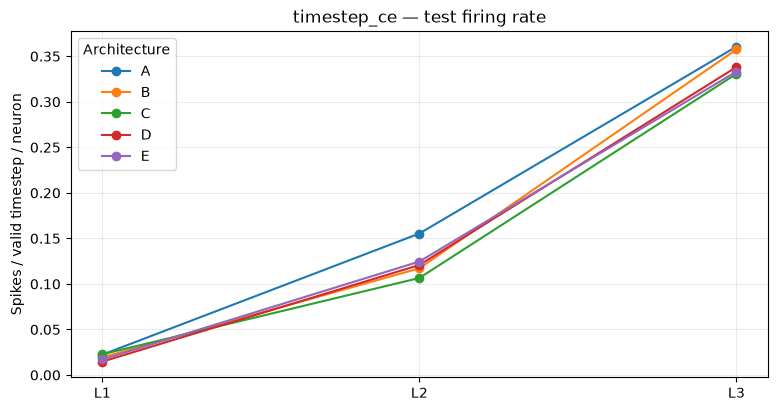

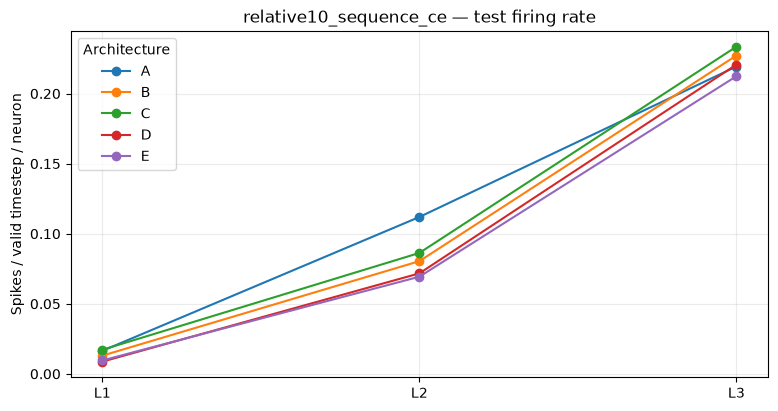

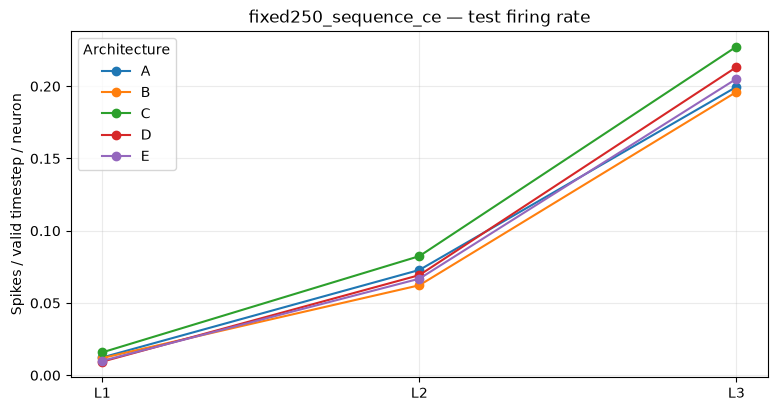

In [6]:
d = firing_summary[(firing_summary['split'] == 'test') & (firing_summary.scope == 'whole_layer')]
for objective in objectives:
    fig, ax = plt.subplots(figsize=(9, 4.5))
    q = d[d.objective == objective]
    for architecture in architectures:
        z = q[q.architecture == architecture].set_index('layer').reindex(['L1', 'L2', 'L3'])
        ax.plot(['L1', 'L2', 'L3'], z.mean_firing_rate, marker='o', label=architecture)
    ax.set_title(f'{objective} — test firing rate')
    ax.set_ylabel('Spikes / valid timestep / neuron')
    ax.grid(alpha=0.25)
    ax.legend(title='Architecture')
    plt.show()


## 5. τ-subgroup probes and firing rates
Only genuinely multi-τ layers are included. Compare subgroups mainly **within the same layer/configuration**, because subgroup feature dimensions can differ across architectures.

,objective,architecture,layer,shift,tau_syn_ms,group_neurons,probe_type,mean_feature_dim,mean_probe_val_balanced_accuracy,mean_probe_test_balanced_accuracy,mean_probe_test_macro_f1,mean_probe_test_accuracy,sd_feature_dim,sd_probe_val_balanced_accuracy,sd_probe_test_balanced_accuracy,sd_probe_test_macro_f1,sd_probe_test_accuracy
0,fixed250_sequence_ce,B,L1,2,54.313430,64,fixed250,1024.0,0.229634,0.225084,0.194257,0.237443,0.0,0.043456,0.022274,0.025829,0.028516
2,fixed250_sequence_ce,B,L1,3,117.013683,64,fixed250,1024.0,0.447431,0.476113,0.470287,0.484018,0.0,0.058591,0.009451,0.016562,0.010463
1,fixed250_sequence_ce,B,L1,2,54.313430,64,full_count,64.0,0.175882,0.171241,0.145439,0.182648,0.0,0.038535,0.027614,0.019123,0.032369
3,fixed250_sequence_ce,B,L1,3,117.013683,64,full_count,64.0,0.359135,0.352109,0.338464,0.360731,0.0,0.015603,0.023079,0.027587,0.025931
4,fixed250_sequence_ce,B,L2,2,54.313430,64,fixed250,1024.0,0.404018,0.409560,0.389986,0.417808,0.0,0.053064,0.055087,0.058957,0.059317
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
122,timestep_ce,E,L2,3,117.013683,43,fixed250,688.0,0.420793,0.504413,0.498263,0.513699,0.0,0.029098,0.019160,0.015330,0.024696
124,timestep_ce,E,L2,4,242.103471,42,fixed250,672.0,0.495246,0.513360,0.504532,0.527397,0.0,0.021302,0.012611,0.003148,0.011863
121,timestep_ce,E,L2,2,54.313430,43,full_count,43.0,0.344561,0.396803,0.379040,0.406393,0.0,0.038604,0.043399,0.052033,0.045605
123,timestep_ce,E,L2,3,117.013683,43,full_count,43.0,0.362795,0.407706,0.393791,0.422374,0.0,0.014384,0.002388,0.008803,0.003954


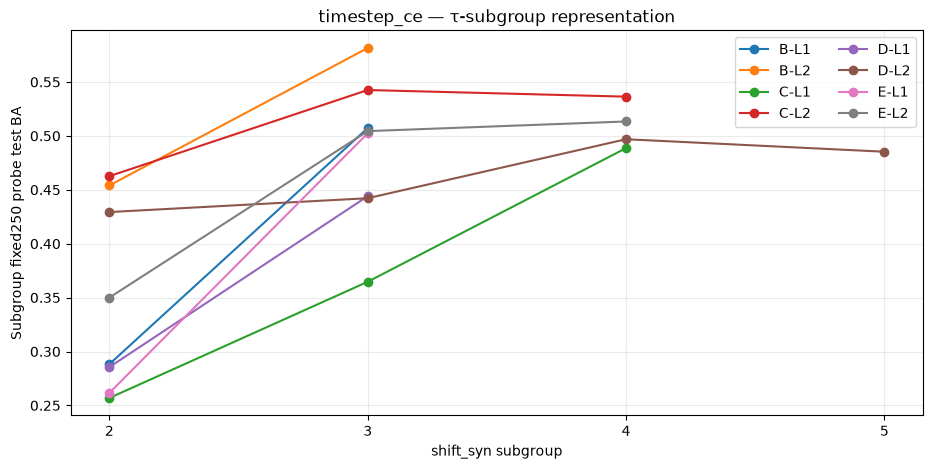

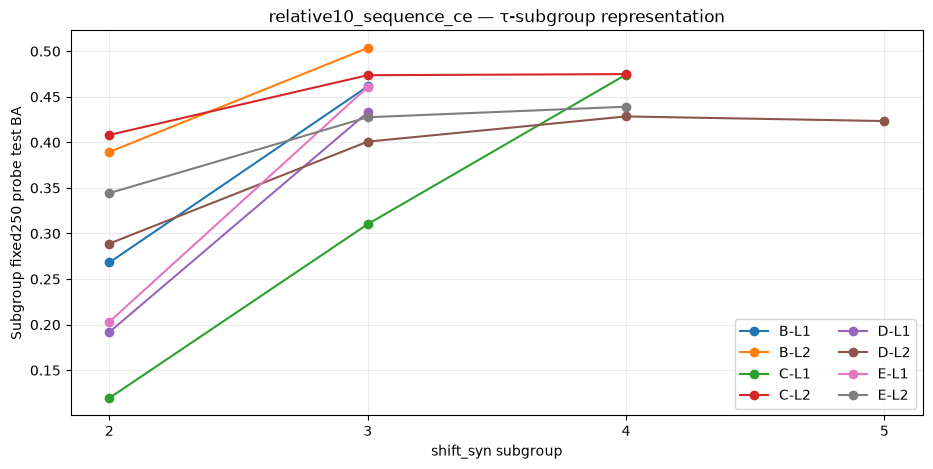

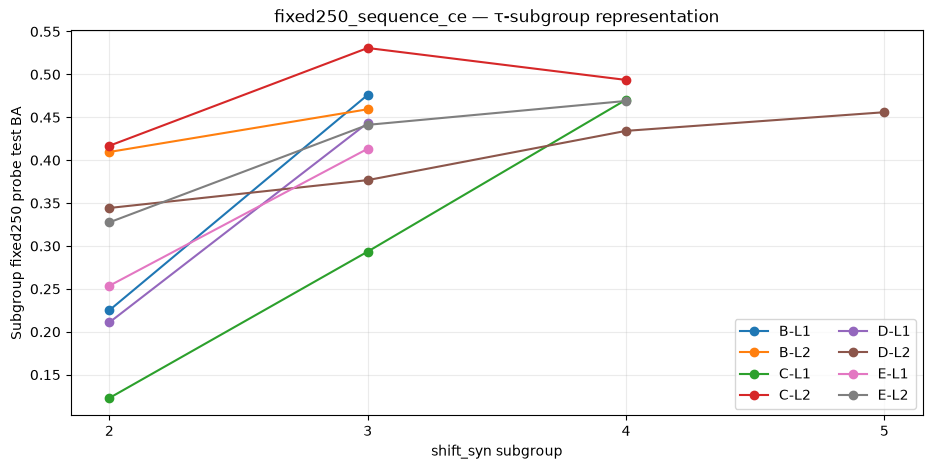

In [7]:
if len(subgroup_probe_summary):
    display(subgroup_probe_summary.sort_values(['objective', 'architecture', 'layer', 'probe_type', 'shift']))

    for objective in objectives:
        d = subgroup_probe_summary[(subgroup_probe_summary.objective == objective) & (subgroup_probe_summary.probe_type == 'fixed250')]
        fig, ax = plt.subplots(figsize=(11, 5))
        for (architecture, layer), q in d.groupby(['architecture', 'layer']):
            q = q.sort_values('shift')
            ax.plot(q['shift'], q.mean_probe_test_balanced_accuracy, marker='o', label=f'{architecture}-{layer}')
        ax.set_xticks([2, 3, 4, 5])
        ax.set_xlabel('shift_syn subgroup')
        ax.set_ylabel('Subgroup fixed250 probe test BA')
        ax.set_title(f'{objective} — τ-subgroup representation')
        ax.grid(alpha=0.25)
        ax.legend(ncol=2)
        plt.show()


In [8]:
sub_fr = firing_summary[(firing_summary['split'] == 'test') & (firing_summary.scope == 'tau_subgroup')]
display(sub_fr.sort_values(['objective', 'architecture', 'layer', 'shift']))


,objective,architecture,split,scope,layer,shift,mean_neurons,mean_firing_rate,sd_neurons,sd_firing_rate
9,fixed250_sequence_ce,B,test,tau_subgroup,L1,2,64.0,0.001496,0.0,0.000395
10,fixed250_sequence_ce,B,test,tau_subgroup,L1,3,64.0,0.022355,0.0,0.004303
11,fixed250_sequence_ce,B,test,tau_subgroup,L2,2,64.0,0.035397,0.0,0.007714
12,fixed250_sequence_ce,B,test,tau_subgroup,L2,3,64.0,0.089175,0.0,0.012022
30,fixed250_sequence_ce,C,test,tau_subgroup,L1,2,43.0,0.000307,0.0,0.000032
...,...,...,...,...,...,...,...,...,...,...
300,timestep_ce,E,test,tau_subgroup,L1,2,64.0,0.002426,0.0,0.000524
301,timestep_ce,E,test,tau_subgroup,L1,3,64.0,0.031654,0.0,0.004015
302,timestep_ce,E,test,tau_subgroup,L2,2,43.0,0.039155,0.0,0.010605
303,timestep_ce,E,test,tau_subgroup,L2,3,43.0,0.091900,0.0,0.025993


## 6. Validation trajectories
A uses the original Experiment 3.0.1 history; B–E use the new Experiment 3.0.2 histories.

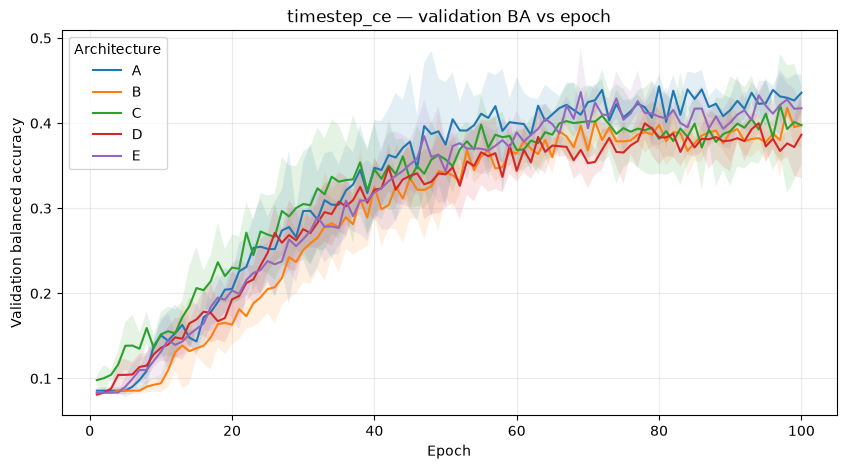

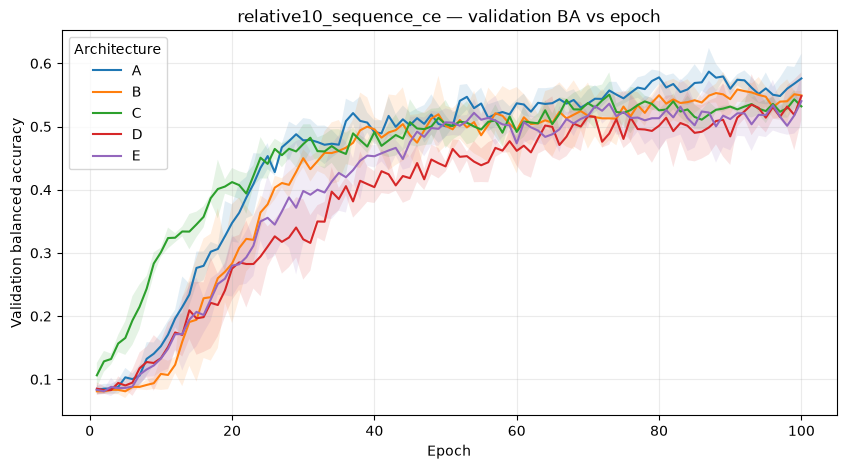

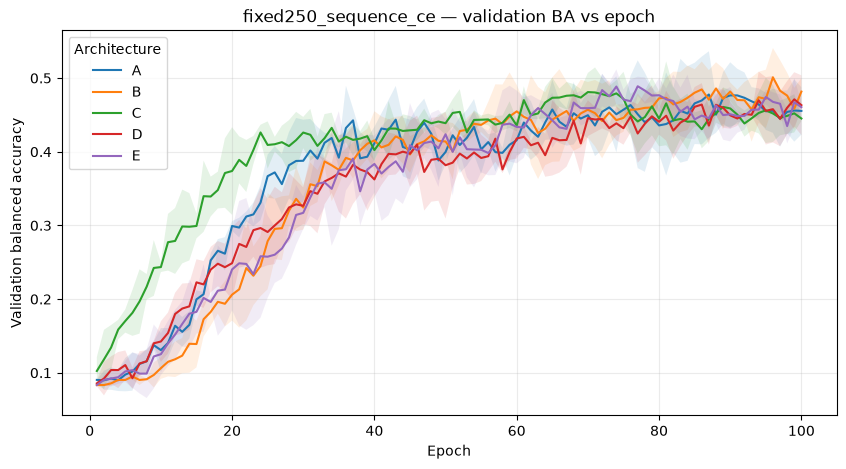

In [9]:
for objective in objectives:
    fig, ax = plt.subplots(figsize=(10, 5))
    q = history[history.objective == objective]
    for architecture in architectures:
        a = q[q.architecture == architecture]
        curve = a.groupby('epoch').val_balanced_accuracy.agg(['mean', 'std']).reset_index()
        ax.plot(curve.epoch, curve['mean'], label=architecture)
        ax.fill_between(curve.epoch, curve['mean'] - curve['std'].fillna(0), curve['mean'] + curve['std'].fillna(0), alpha=0.12)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Validation balanced accuracy')
    ax.set_title(f'{objective} — validation BA vs epoch')
    ax.grid(alpha=0.25)
    ax.legend(title='Architecture')
    plt.show()


## 7. Rankings


In [10]:
print('Native ranking')
display(native_summary.sort_values('mean_test_balanced_accuracy', ascending=False)[['objective', 'architecture', 'mean_test_balanced_accuracy', 'sd_test_balanced_accuracy', 'mean_train_test_ba_gap']])

print('L3 fixed250 frozen-probe ranking')
display(l3.sort_values('mean_probe_test_balanced_accuracy', ascending=False)[['objective', 'architecture', 'mean_probe_test_balanced_accuracy', 'sd_probe_test_balanced_accuracy']])


Native ranking


,objective,architecture,mean_test_balanced_accuracy,sd_test_balanced_accuracy,mean_train_test_ba_gap
6,relative10_sequence_ce,B,0.586775,0.020078,0.382404
5,relative10_sequence_ce,A,0.568385,0.032652,0.405412
7,relative10_sequence_ce,C,0.561331,0.031037,0.415524
8,relative10_sequence_ce,D,0.555582,0.080525,0.400366
9,relative10_sequence_ce,E,0.532746,0.023980,0.406348
2,fixed250_sequence_ce,C,0.490975,0.020595,0.482288
1,fixed250_sequence_ce,B,0.484617,0.023961,0.459917
12,timestep_ce,C,0.462039,0.049581,0.367987
4,fixed250_sequence_ce,E,0.457082,0.027618,0.495397
10,timestep_ce,A,0.453668,0.038418,0.319611


L3 fixed250 frozen-probe ranking


,objective,architecture,mean_probe_test_balanced_accuracy,sd_probe_test_balanced_accuracy
70,timestep_ce,B,0.565731,0.015855
64,timestep_ce,A,0.555879,0.048933
88,timestep_ce,E,0.530763,0.061772
40,relative10_sequence_ce,B,0.529576,0.021272
34,relative10_sequence_ce,A,0.529129,0.042170
4,fixed250_sequence_ce,A,0.525037,0.036430
16,fixed250_sequence_ce,C,0.523881,0.015747
76,timestep_ce,C,0.512149,0.022337
82,timestep_ce,D,0.508984,0.033408
28,fixed250_sequence_ce,E,0.506922,0.043149
